In [5]:
#Import libraries
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [7]:
#Read file
df = pd.read_csv("../../data/processed/Customers.csv")

In [8]:
#Remove CustomerID from dataframe since no predictive power.  Renamed column names to snake case for easier reference in code
df = df.drop(columns=["CustomerID"]).rename(
    columns = {
        'Gender': 'gender',
        'Age': 'age',
        'Annual Income': 'annual_income',
        'Spending Score': 'spending_score',
        'Profession': 'profession',
        'Work Experience': 'work_experience',
        'Family Size': 'family_size',
    }
)

In [10]:
# Select features for segmentation
X = df[["annual_income", "spending_score"]]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

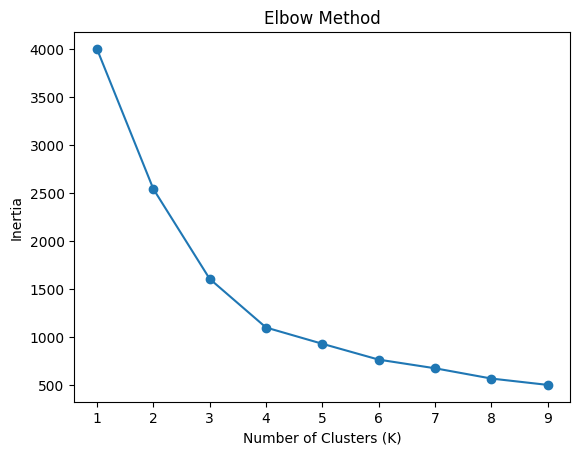

In [11]:
#Find optimal K using KMeans clustering
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [12]:
#Use Silhouette score to measure how well each data point fits within its assigned cluster compared to other clusters. 
from sklearn.metrics import silhouette_score

X = df[["annual_income", "spending_score"]]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.3449
K = 3, Silhouette Score = 0.3737
K = 4, Silhouette Score = 0.3819
K = 5, Silhouette Score = 0.3664
K = 6, Silhouette Score = 0.3627
K = 7, Silhouette Score = 0.3531
K = 8, Silhouette Score = 0.3584


In [13]:
#Fit model using k=4
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster1"] = kmeans.fit_predict(X_scaled)

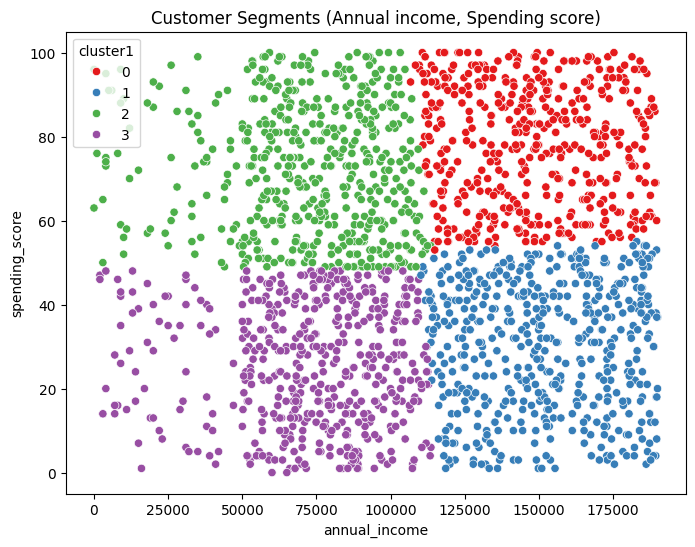

In [14]:
#Cluster visual
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="annual_income",
    y="spending_score",
    hue="cluster1",
    palette="Set1",
    data=df
)
plt.title("Customer Segments (Annual income, Spending score)")
plt.show()

This cluster shows Spending is not driven by Income
1. High Income and High Spending (Red)
2. High Income and Low Spending (Blue)
3. Moderate Income and High Spendign (Green)
4. Moderate Income and Low Spending (Purple)



In [15]:
#Compute silhouette score for KMeans clustering using age and spendig score
from sklearn.metrics import silhouette_score

X = df[["age", "spending_score"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.3405
K = 3, Silhouette Score = 0.3705
K = 4, Silhouette Score = 0.3924
K = 5, Silhouette Score = 0.3760
K = 6, Silhouette Score = 0.3620
K = 7, Silhouette Score = 0.3527
K = 8, Silhouette Score = 0.3716


In [16]:
#Fit model using k=4 since it is the best score
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster2"] = kmeans.fit_predict(X_scaled)

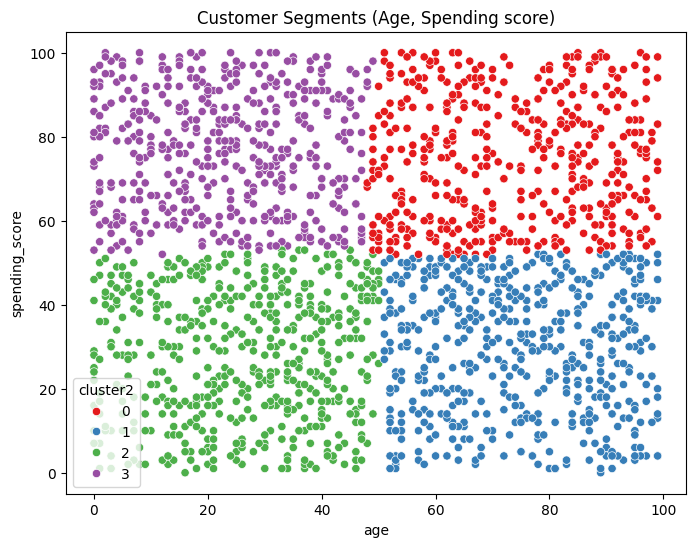

In [17]:
#Visualizing cluster
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="age",
    y="spending_score",
    hue="cluster2",
    palette="Set1",
    data=df
)
plt.title("Customer Segments (Age, Spending score)")
plt.show()

This cluster shows Spending is not driven by Age alone.
1. High Age and High Spending (Red)
2. High Age and Low Spending (Blue)
3. Low Age and Low Spending (Green)
4. Low Age and High Spending (Purple)


In [18]:
#Compute silhouette score for KMeans clustering using family size and spendig score
from sklearn.metrics import silhouette_score

X = df[["family_size", "spending_score"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.3558
K = 3, Silhouette Score = 0.3893
K = 4, Silhouette Score = 0.3916
K = 5, Silhouette Score = 0.3814
K = 6, Silhouette Score = 0.3641
K = 7, Silhouette Score = 0.3864
K = 8, Silhouette Score = 0.3838


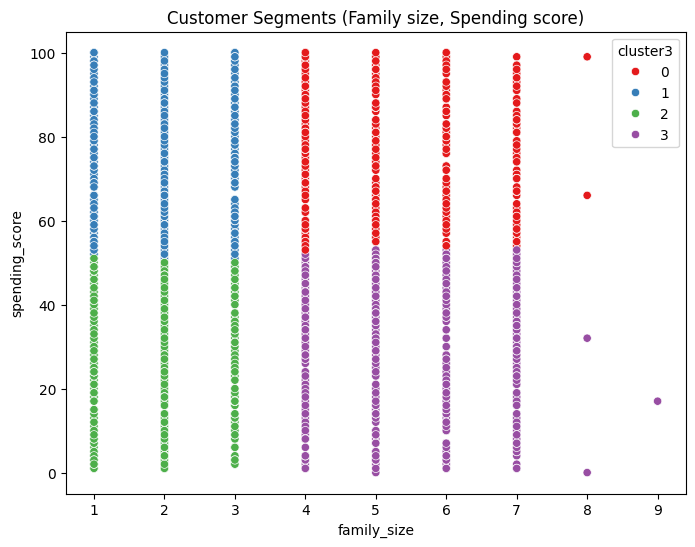

In [19]:
#Fit model using k=4 since it is the best score
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster3"] = kmeans.fit_predict(X_scaled)

#Visualizing cluster
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="family_size",
    y="spending_score",
    hue="cluster3",
    palette="Set1",
    data=df
)
plt.title("Customer Segments (Family size, Spending score)")
plt.show()

No clear realtionship between family size and spending.

In [20]:
#Segment analysis by combining input features Age and annual income with spending score
X = df[["age", "annual_income", "spending_score"]]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [22]:
#Use 4 clusters to fit model
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster4"] = kmeans.fit_predict(X_scaled)

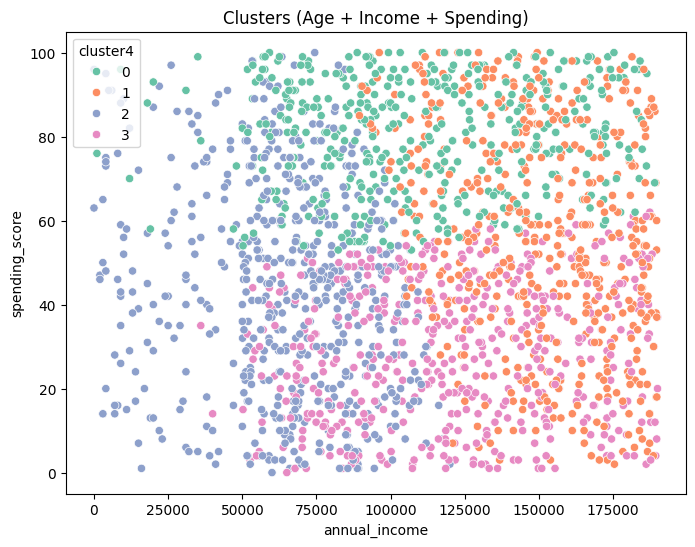

In [23]:
#visualize cluster
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="annual_income",
    y="spending_score",
    hue="cluster4",
    palette="Set2",
    data=df
)
plt.title("Clusters (Age + Income + Spending)")
plt.show()

##After combining age with annual income clusters don't show clear separation like before. So combining features does not create any additional strength.

In [29]:
#Building a pipeline for categorical input gender to see any pattern
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["spending_score"]),
        ("cat", OneHotEncoder(), ["gender"])
    ]
)

kmeans_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("kmeans", KMeans(n_clusters=4, random_state=42))
])
df["cluster5"] = kmeans_pipe.fit_predict(df)

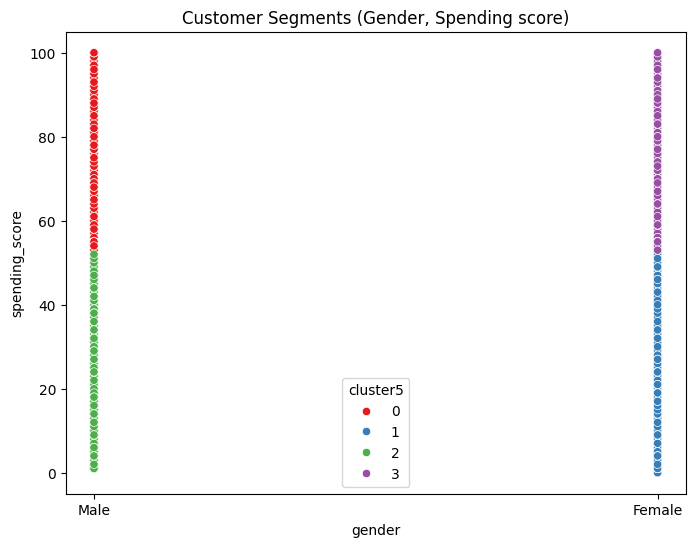

In [30]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="gender",
    y="spending_score",
    hue="cluster5",
    palette="Set1",
    data=df
)
plt.title("Customer Segments (Gender, Spending score)")
plt.show()